In [1]:
import numpy as np 
import matplotlib.pyplot as plt 
import glob
import pandas as pd
from shapely.geometry import Polygon
from sklearn.model_selection import train_test_split
import xgboost as xgb
from sklearn.preprocessing import LabelEncoder

In [2]:
boundary_files = glob.glob("./phasemap_data/v3/*.csv")
points_files = glob.glob("./phasemap_data/v3/*.csv")
labels = ["disorder", "hex", "hpl", "Im3m", "Ia3d", "lam"]

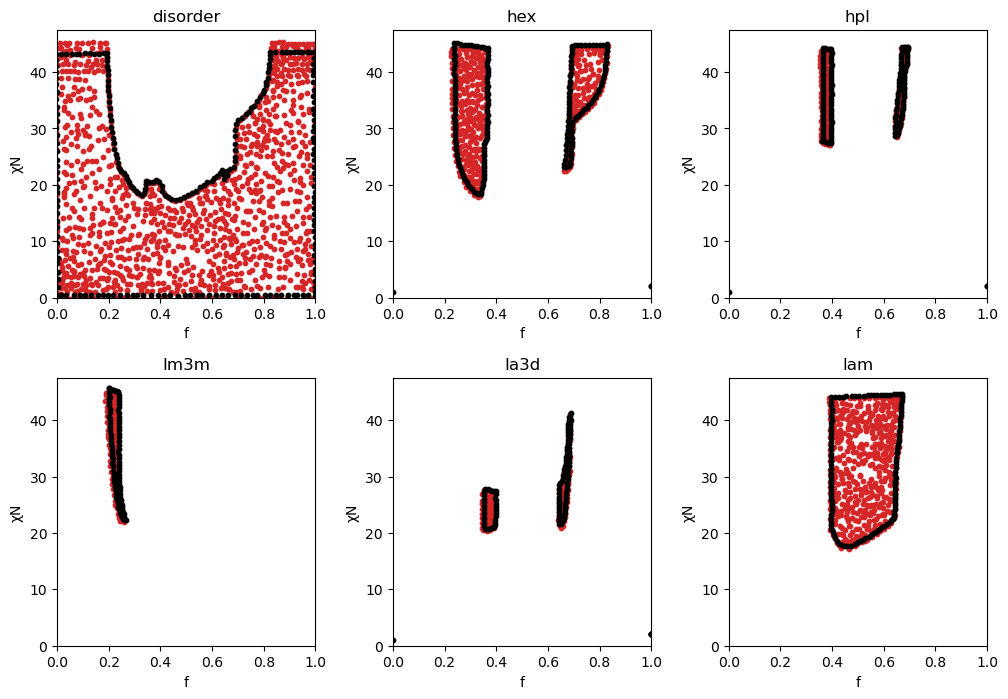

In [3]:
fig, axs = plt.subplots(2,3, figsize=(4*3, 4*2))
fig.subplots_adjust(wspace=0.3, hspace=0.3)
axs = axs.flatten()
clf_data = []
polygons_and_labels = []
for i,label in enumerate(labels):
    boundary_df = pd.read_csv("./phasemap_data/v3/boundaries/%s.csv"%label, header=None)
    boundary_df = boundary_df.rename(columns={0: 'f', 1: 'xN'})
    boundary_points = boundary_df[['f', 'xN']].values

    points_df = pd.read_csv("./phasemap_data/v3/points/%s.csv"%label, header=None)
    points_df = points_df.rename(columns={0: 'f', 1: 'xN'})
    sampled_points = points_df.to_numpy()
    num_samples = sampled_points.shape[0]

    labeled_points = np.hstack((sampled_points, (np.asarray([label]*num_samples)).reshape(-1,1)))
    clf_data.append(labeled_points)

    ax = axs[i]
    ax.scatter(*sampled_points.T, s=10, color='tab:red')
    ax.scatter(boundary_df['f'], boundary_df['xN'], color="k", s=10)
    ax.set_xlabel('f')
    ax.set_ylabel('χN')
    ax.set_title(label)
    ax.set_xlim([0, 1.0])
    ax.set_ylim([0, 47.5])
plt.show()

In [4]:
# Use sampled points in the polygon as the train data
X = np.vstack(clf_data)[:, :2].astype(np.float32)
le = LabelEncoder()
y = le.fit_transform(np.vstack(clf_data)[:, 2])

In [5]:
X_train, X_test, y_train, y_test = train_test_split(X, y, stratify=y)
clf = xgb.XGBClassifier(tree_method="hist", early_stopping_rounds=10)
clf.fit(X_train, y_train, eval_set=[(X_test, y_test)])
# clf.save_model("clf.json")

[0]	validation_0-mlogloss:1.18584
[1]	validation_0-mlogloss:0.90982
[2]	validation_0-mlogloss:0.73693
[3]	validation_0-mlogloss:0.61944
[4]	validation_0-mlogloss:0.53446
[5]	validation_0-mlogloss:0.47209
[6]	validation_0-mlogloss:0.42869
[7]	validation_0-mlogloss:0.39771
[8]	validation_0-mlogloss:0.37592
[9]	validation_0-mlogloss:0.36004
[10]	validation_0-mlogloss:0.34774
[11]	validation_0-mlogloss:0.33826
[12]	validation_0-mlogloss:0.33082
[13]	validation_0-mlogloss:0.32451
[14]	validation_0-mlogloss:0.32168
[15]	validation_0-mlogloss:0.32071
[16]	validation_0-mlogloss:0.32137
[17]	validation_0-mlogloss:0.31920
[18]	validation_0-mlogloss:0.31923
[19]	validation_0-mlogloss:0.31892
[20]	validation_0-mlogloss:0.31996
[21]	validation_0-mlogloss:0.32008
[22]	validation_0-mlogloss:0.32153
[23]	validation_0-mlogloss:0.32288
[24]	validation_0-mlogloss:0.32486
[25]	validation_0-mlogloss:0.32658
[26]	validation_0-mlogloss:0.32808
[27]	validation_0-mlogloss:0.33093
[28]	validation_0-mlogloss:0.3

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=10,
              enable_categorical=False, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=None, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=None,
              n_jobs=None, num_parallel_tree=None, ...)

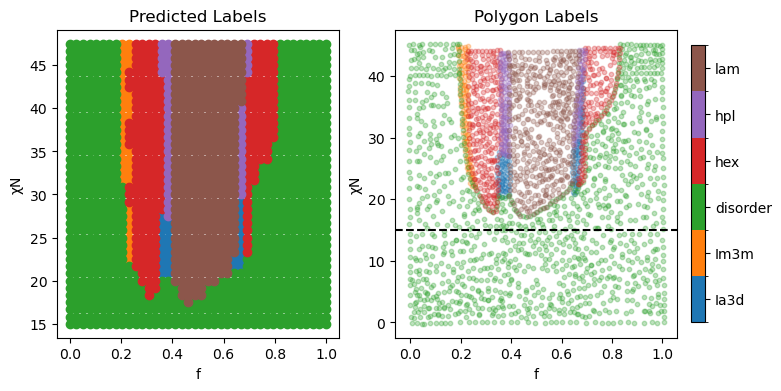

In [61]:
import matplotlib.colors as mcolors
from matplotlib.cm import ScalarMappable

base_cmap = plt.get_cmap('tab10') 
colors = base_cmap.colors
N = len(labels)
selected_colors = [colors[i % 10] for i in range(N)]
cmap = mcolors.ListedColormap(selected_colors, name=f'tab10_{N}')
norm = mcolors.BoundaryNorm(np.arange(N+1), cmap.N)
mappable = ScalarMappable(norm=norm, cmap=cmap)

xaxis = np.linspace(0.0, 1.0, 40)
yaxis = np.linspace(15.0, 47.5, 40)

x_grid, y_grid = np.meshgrid(xaxis, yaxis)
grid = np.vstack([x_grid.ravel(), y_grid.ravel()]).T
labels_pred = clf.predict(grid)

fig, axs = plt.subplots(1,2, figsize=(4*2, 4*1))
ax = axs[0]
for i in range(len(labels)):
    ax.scatter(grid[labels_pred==i,0], 
               grid[labels_pred==i,1],
               color = cmap(norm(i))
            )
    
ax.set_xlabel('f')
ax.set_ylabel('χN')
ax.set_title('Predicted Labels')

ax = axs[1]
for i in range(len(labels)):
    ax.scatter(X[y==i,0], 
            X[y==i,1], 
            color = cmap(norm(i)), 
            s=10, 
            alpha = 0.3
            )
ax.axhline(y=15.0, color="k", ls="--")
ax.set_xlabel('f')
ax.set_ylabel('χN')
ax.set_title('Polygon Labels')

cax = ax.inset_axes([1.05, 0.05, 0.05, 0.9], transform=ax.transAxes)
cbar = fig.colorbar(mappable, shrink=0.5, aspect=5, cax=cax)
tick_locs = cax.get_yticks()  
new_tick_locs = (tick_locs[:-1] + tick_locs[1:]) / 2
cbar.set_ticks(new_tick_locs)
cbar.ax.set_yticklabels(le.classes_)
plt.show()